### Patient List Processing

Read TRAP-PARDS_cxr.xlsx file, Crosswalk.csv file, and create a index list for all dcm files

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Load all sheets from TRAP-PARDS_cxr.xlsx, load Crosswalk.csv,
and recursively list all DICOM (.dcm) files under HUM00237109.
"""

import pandas as pd
from pathlib import Path

# ---------- Paths ----------
excel_path = Path("/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXR(from_Joe)/TRAP-PARDS_cxr.xlsx")
crosswalk_path = Path("/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/HUM00237109/Crosswalk.csv")
dicom_root = Path("/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/HUM00237109")

# ---------- Load Excel (all sheets) ----------
print("🔹 Loading Excel file...")
all_sheets = pd.read_excel(excel_path, sheet_name=None, engine="openpyxl")

print(f"\n✅ Loaded {len(all_sheets)} sheet(s) from '{excel_path.name}'\n")
print("📄 Sheet names:")
for name in all_sheets.keys():
    print(f" - {name}")

print("\n🔍 Preview of each sheet:\n")
for name, df in all_sheets.items():
    print(f"--- {name} --- shape={df.shape}")
    # print(df.head())
    print()

# Example: access specific sheet
# df_demo = all_sheets["Sheet1"]

# ---------- Load Crosswalk.csv ----------
print("🔹 Loading Crosswalk CSV...")
crosswalk_df = pd.read_csv(crosswalk_path)
print(f"✅ Crosswalk loaded: shape={crosswalk_df.shape}\n")
# print(crosswalk_df.head())

# ---------- Find DICOM files recursively ----------
print("\n🔹 Searching for DICOM (.dcm) files recursively...")
dicom_files = [p for p in dicom_root.rglob("*") if p.is_file() and p.suffix.lower() == ".dcm"]
dicom_files = sorted(set(dicom_files))

print(f"✅ Found {len(dicom_files)} DICOM file(s) under '{dicom_root}'\n")

# # Show a preview of first 10 DICOM files
# for p in dicom_files[:10]:
#     print(f" - {p}")
# if len(dicom_files) > 10:
#     print(f"... (+{len(dicom_files) - 10} more)")

# # ---------- Optional: Save DICOM list to CSV ----------
# dicom_index_path = dicom_root / "dicom_index.csv"
# try:
#     pd.DataFrame({"dicom_path": [str(p) for p in dicom_files]}).to_csv(dicom_index_path, index=False)
#     print(f"\n💾 DICOM file list saved to: {dicom_index_path}")
# except Exception as e:
#     print(f"⚠️ Could not save dicom_index.csv: {e}")


🔹 Loading Excel file...

✅ Loaded 5 sheet(s) from 'TRAP-PARDS_cxr.xlsx'

📄 Sheet names:
 - Query Specifications
 - Chest X-Ray Or...cession Number
 - Orders
 - OrdersAccessionNumbers
 - PatientInfo

🔍 Preview of each sheet:

--- Query Specifications --- shape=(17, 3)

--- Chest X-Ray Or...cession Number --- shape=(11257, 45)

--- Orders --- shape=(29056, 39)

--- OrdersAccessionNumbers --- shape=(329685, 6)

--- PatientInfo --- shape=(899, 2)

🔹 Loading Crosswalk CSV...
✅ Crosswalk loaded: shape=(2970, 3)


🔹 Searching for DICOM (.dcm) files recursively...
✅ Found 3123 DICOM file(s) under '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/HUM00237109'



In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Count how many subfolders (studies) each MRN folder has under HUM00237109
and save results to mrn_subfolder_counts.csv.
"""

from pathlib import Path
import pandas as pd

# ---------- Root path ----------
root = Path("/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/HUM00237109")

# ---------- Output CSV ----------
out_csv = root / "mrn_subfolder_counts.csv"

# ---------- Traverse ----------
data = []
total_subfolders = 0

print(f"[INFO] Scanning MRN folders under:\n{root}\n")

for mrn_folder in sorted(root.iterdir()):
    if not mrn_folder.is_dir():
        continue

    # Collect all subfolders directly under each MRN folder
    subfolders = [p for p in mrn_folder.iterdir() if p.is_dir()]
    count = len(subfolders)
    total_subfolders += count

    data.append({
        "MRN": mrn_folder.name,
        "SubfolderCount": count,
    })

    # Optional progress display
    if len(data) % 50 == 0:
        print(f"  Processed {len(data)} MRNs...")

# ---------- Save results ----------
df = pd.DataFrame(data).sort_values("MRN").reset_index(drop=True)
df.to_csv(out_csv, index=False)

print(f"\n✅ Results saved to: {out_csv}")
print(f"📊 Total MRN folders: {len(df)}")
print(f"📁 Total subfolders across all MRNs: {total_subfolders}")

# ---------- Optional preview ----------
print("\nFirst few entries:")
print(df.head(10))


[INFO] Scanning MRN folders under:
/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/HUM00237109

  Processed 50 MRNs...
  Processed 100 MRNs...
  Processed 150 MRNs...
  Processed 200 MRNs...
  Processed 250 MRNs...
  Processed 300 MRNs...
  Processed 350 MRNs...
  Processed 400 MRNs...
  Processed 450 MRNs...

✅ Results saved to: /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/HUM00237109/mrn_subfolder_counts.csv
📊 Total MRN folders: 470
📁 Total subfolders across all MRNs: 2444

First few entries:
          MRN  SubfolderCount
0  142427_001               2
1  142427_002               6
2  142427_003               1
3  142427_004               2
4  142427_005               1
5  142427_006               2
6  142427_007               1
7  142427_008               7
8  142427_009               2
9  142427_010               7


Match information to the Crosswalk.csv file

In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Audit whether DICOM filenames contain Study/Series/SOP UIDs.

Outputs (under HUM00237109):
- uid_filename_audit.csv : per-file booleans indicating whether the filename contains each UID
- uid_filename_audit_summary.txt : counts & percentages
"""

from pathlib import Path
import pandas as pd
import pydicom

ROOT = Path("/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/HUM00237109")
INDEX = ROOT / "dicom_index.csv"

OUT_CSV = ROOT / "uid_filename_audit.csv"
OUT_TXT = ROOT / "uid_filename_audit_summary.txt"

def list_dicoms():
    if INDEX.exists():
        df = pd.read_csv(INDEX, dtype=str)
        if "dicom_path" in df.columns:
            paths = df["dicom_path"].dropna()
            return [p for p in paths if p.strip()]
    # fallback: walk filesystem
    return [str(p) for p in ROOT.rglob("*.dcm")]

def contains(hay: str | None, needle: str | None) -> bool:
    if not hay or not needle:
        return False
    return needle in hay

def main():
    paths = list_dicoms()
    if not paths:
        print("[ERROR] No DICOM files found.")
        return

    rows = []
    for i, p in enumerate(paths, 1):
        pth = Path(p)
        fname = pth.name
        try:
            ds = pydicom.dcmread(p, stop_before_pixels=True, force=True)
            study_uid  = getattr(ds, "StudyInstanceUID", None)
            series_uid = getattr(ds, "SeriesInstanceUID", None)
            sop_uid    = getattr(ds, "SOPInstanceUID", None)

            row = {
                "dicom_path": p,
                "filename": fname,
                "StudyInstanceUID": study_uid,
                "SeriesInstanceUID": series_uid,
                "SOPInstanceUID": sop_uid,
                "filename_has_StudyUID":  contains(fname, study_uid),
                "filename_has_SeriesUID": contains(fname, series_uid),
                "filename_has_SOPUID":    contains(fname, sop_uid),
            }
        except Exception as e:
            row = {
                "dicom_path": p,
                "filename": fname,
                "StudyInstanceUID": None,
                "SeriesInstanceUID": None,
                "SOPInstanceUID": None,
                "filename_has_StudyUID":  False,
                "filename_has_SeriesUID": False,
                "filename_has_SOPUID":    False,
                "read_error": str(e),
            }
        rows.append(row)
        if i % 1000 == 0 or i == len(paths):
            print(f"Processed {i}/{len(paths)}")

    df = pd.DataFrame(rows)
    df.to_csv(OUT_CSV, index=False)

    # Summarize
    total = len(df)
    c_study  = int(df["filename_has_StudyUID"].sum())
    c_series = int(df["filename_has_SeriesUID"].sum())
    c_sop    = int(df["filename_has_SOPUID"].sum())
    c_err    = int(df["StudyInstanceUID"].isna().sum())

    pct = lambda c: f"{(100.0*c/total):.2f}%" if total else "0.00%"

    summary_lines = [
        f"Total DICOM files: {total}",
        f"Filename contains StudyInstanceUID : {c_study} ({pct(c_study)})",
        f"Filename contains SeriesInstanceUID: {c_series} ({pct(c_series)})",
        f"Filename contains SOPInstanceUID   : {c_sop} ({pct(c_sop)})",
        f"Header read failures (any UID null): {c_err}",
        "",
        "Note: Exporters often name files by SOPInstanceUID, not StudyInstanceUID.",
        "      Use StudyInstanceUID (0020,000D) to define 'studies' and match Crosswalk rows.",
    ]
    OUT_TXT.write_text("\n".join(summary_lines), encoding="utf-8")
    print("\n".join(summary_lines))
    print(f"\nSaved per-file audit to: {OUT_CSV}")
    print(f"Saved summary to: {OUT_TXT}")

if __name__ == "__main__":
    main()


Processed 1000/3123
Processed 2000/3123
Processed 3000/3123
Processed 3123/3123
Total DICOM files: 3123
Filename contains StudyInstanceUID : 0 (0.00%)
Filename contains SeriesInstanceUID: 0 (0.00%)
Filename contains SOPInstanceUID   : 3123 (100.00%)
Header read failures (any UID null): 0

Note: Exporters often name files by SOPInstanceUID, not StudyInstanceUID.
      Use StudyInstanceUID (0020,000D) to define 'studies' and match Crosswalk rows.

Saved per-file audit to: /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/HUM00237109/uid_filename_audit.csv
Saved summary to: /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/HUM00237109/uid_filename_audit_summary.txt


In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Reconcile Crosswalk (De-ID MRN, De-ID ACC) with DICOM studies (StudyInstanceUID).
Primary match by AccessionNumber; fallback map by MRN-wise ordering.

Outputs (in HUM00237109):
- studies_all.csv                 : one row per (MRN, StudyInstanceUID) + counts/meta
- acc_primary_matches.csv         : Crosswalk rows matched by AccessionNumber (high-confidence)
- acc_fallback_matches.csv        : Remaining Crosswalk rows matched by positional fallback
- acc_unmatched_crosswalk.csv     : Crosswalk rows with no DICOM match
- acc_unmatched_studies.csv       : Studies with no Crosswalk row
- folder_multiplicity.csv         : Direct parent folder → # distinct StudyInstanceUIDs
- study_accession_ambiguity.csv   : Studies that contain multiple distinct AccessionNumbers
- reconcile_summary.txt           : Human-readable summary (counts, suggested causes)
"""

from pathlib import Path
import re
from collections import defaultdict
import pandas as pd
import pydicom

# ---------------- Paths ----------------
ROOT = Path("/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/HUM00237109")
CROSSWALK = ROOT / "Crosswalk.csv"
INDEX = ROOT / "dicom_index.csv"

OUT_STUDIES   = ROOT / "studies_all.csv"
OUT_PRIM      = ROOT / "acc_primary_matches.csv"
OUT_FALLBACK  = ROOT / "acc_fallback_matches.csv"
OUT_XW_UNM    = ROOT / "acc_unmatched_crosswalk.csv"
OUT_STD_UNM   = ROOT / "acc_unmatched_studies.csv"
OUT_FOLDER    = ROOT / "folder_multiplicity.csv"
OUT_AMBIG     = ROOT / "study_accession_ambiguity.csv"
OUT_SUMMARY   = ROOT / "reconcile_summary.txt"

# -------------- Helpers --------------
def list_dicoms():
    if INDEX.exists():
        df = pd.read_csv(INDEX, dtype=str)
        if "dicom_path" not in df.columns:
            raise RuntimeError(f"{INDEX} missing 'dicom_path' column")
        return sorted(df["dicom_path"].dropna().tolist())
    return sorted(str(p) for p in ROOT.rglob("*.dcm"))

def extract_mrn_and_parent(path_str: str):
    p = Path(path_str)
    try:
        rel = p.resolve().relative_to(ROOT.resolve())
        parts = rel.parts
        mrn = parts[0] if len(parts) >= 1 else None
        parent = str(p.parent)
        return mrn, parent
    except Exception:
        m = re.search(r"/HUM00237109/([^/]+)/", path_str)
        mrn = m.group(1) if m else None
        return mrn, str(Path(path_str).parent)

def parse_int(x):
    try:
        return int(x)
    except Exception:
        return None

def acc_index_from_deid(deid_acc: str, mrn: str):
    """Return NN from '<MRN>-NN' or None if malformed."""
    if not isinstance(deid_acc, str):
        return None
    m = re.match(rf"^{re.escape(mrn)}-(\d+)$", deid_acc.strip())
    return int(m.group(1)) if m else None

def first_nonempty(series):
    for v in series:
        if pd.notna(v) and str(v) != "":
            return v
    return ""

def min_int(series):
    ints = [parse_int(x) for x in series if parse_int(x) is not None]
    return min(ints) if ints else 9999999

# -------------- 1) Read headers --------------
print("[INFO] Listing DICOM files...")
paths = list_dicoms()
if not paths:
    raise SystemExit("No .dcm files found.")

print(f"[INFO] Reading headers from {len(paths)} DICOM files...")
hdr_rows = []
for i, p in enumerate(paths, 1):
    try:
        ds = pydicom.dcmread(p, stop_before_pixels=True, force=True)
        sop   = getattr(ds, "SOPInstanceUID", None)
        study = getattr(ds, "StudyInstanceUID", None)
        series= getattr(ds, "SeriesInstanceUID", None)
        acc   = getattr(ds, "AccessionNumber", None)
        pid   = getattr(ds, "PatientID", None)
        sdate = getattr(ds, "StudyDate", None)
        stime = getattr(ds, "StudyTime", None)
        snum  = getattr(ds, "SeriesNumber", None)
        inum  = getattr(ds, "InstanceNumber", None)
    except Exception:
        sop=study=series=acc=pid=sdate=stime=snum=inum=None
    mrn, parent = extract_mrn_and_parent(p)
    hdr_rows.append({
        "dicom_path": p, "MRN": mrn, "ParentFolder": parent,
        "StudyInstanceUID": study, "SeriesInstanceUID": series, "SOPInstanceUID": sop,
        "AccessionNumber": acc, "PatientID": pid,
        "StudyDate": sdate, "StudyTime": stime,
        "SeriesNumber": snum, "InstanceNumber": inum
    })
    if i % 1000 == 0 or i == len(paths):
        print(f"  - {i}/{len(paths)}")

hdr = pd.DataFrame(hdr_rows)

# -------------- 2) Build studies and folder multiplicity --------------
valid = hdr.dropna(subset=["MRN", "StudyInstanceUID"]).copy()

# Folder multiplicity (detect mixed-study folders)
folder_mult = (
    valid.groupby(["MRN", "ParentFolder"], as_index=False)["StudyInstanceUID"].nunique()
    .rename(columns={"StudyInstanceUID": "DistinctStudyUIDs"})
)
folder_mult["HasMixedStudies"] = folder_mult["DistinctStudyUIDs"] > 1
folder_mult.to_csv(OUT_FOLDER, index=False)
mixed_folders = int(folder_mult["HasMixedStudies"].sum())

# Per (MRN, StudyInstanceUID) aggregate
studies = (
    valid.groupby(["MRN", "StudyInstanceUID"], as_index=False)
    .agg(
        Images=("SOPInstanceUID", "nunique"),
        Series=("SeriesInstanceUID", "nunique"),
        AnyAccession=("AccessionNumber", first_nonempty),
        AnyStudyDate=("StudyDate", first_nonempty),
        AnyStudyTime=("StudyTime", first_nonempty),
        FirstPath=("dicom_path", "min"),
    )
)
studies.to_csv(OUT_STUDIES, index=False)

# For fallback ordering, compute per-study minimal sortable keys
order_refs = (
    valid.groupby(["MRN", "StudyInstanceUID"], as_index=False)
    .agg(
        StudyDate_min=("StudyDate", first_nonempty),
        StudyTime_min=("StudyTime", first_nonempty),
        SeriesNumber_min=("SeriesNumber", min_int),
        InstanceNumber_min=("InstanceNumber", min_int),
        FirstPath=("dicom_path", "min")
    )
)
ordered = (
    order_refs.sort_values(
        ["MRN", "StudyDate_min", "StudyTime_min", "SeriesNumber_min", "InstanceNumber_min", "FirstPath"]
    )
    .groupby("MRN")
    .agg(StudyUIDs=("StudyInstanceUID", list))
    .reset_index()
)
mrn_to_study_list = {r["MRN"]: r["StudyUIDs"] for _, r in ordered.iterrows()}

# -------------- 3) Load Crosswalk --------------
xw = pd.read_csv(CROSSWALK, dtype=str).fillna("")
if not {"De-ID MRN", "De-ID ACC"}.issubset(xw.columns):
    raise SystemExit(f"Crosswalk must have 'De-ID MRN' and 'De-ID ACC' columns. Found: {list(xw.columns)}")
xw["ACC_Index"] = xw.apply(lambda r: acc_index_from_deid(r["De-ID ACC"], r["De-ID MRN"]), axis=1)
xw["__Row"] = range(1, len(xw)+1)

# Deterministic sort of Crosswalk rows per MRN
xw_sorted = (
    xw.sort_values(["De-ID MRN", "ACC_Index", "De-ID ACC", "__Row"], na_position="last")
    .reset_index(drop=True)
)

# -------------- 4) PRIMARY MATCH by AccessionNumber --------------
acc_to_studies = defaultdict(set)  # (MRN, AccessionNumber) -> set(StudyUID)
for _, r in valid.dropna(subset=["AccessionNumber"]).iterrows():
    acc_to_studies[(r["MRN"], r["AccessionNumber"])].add(r["StudyInstanceUID"])

# Studies with multiple distinct accession numbers (data quality)
study_to_accs = valid.groupby(["MRN", "StudyInstanceUID"])["AccessionNumber"].apply(
    lambda s: sorted({a for a in s if pd.notna(a) and str(a)!=""})
).reset_index(name="AccessionNumbers")
ambiguous = study_to_accs[study_to_accs["AccessionNumbers"].map(len) > 1]
ambiguous.to_csv(OUT_AMBIG, index=False)

primary_matches = []
unmatched_mask = [True] * len(xw_sorted)

for i, row in xw_sorted.iterrows():
    mrn = row["De-ID MRN"]
    acc = row["De-ID ACC"]
    cand = list(acc_to_studies.get((mrn, acc), []))
    if len(cand) == 1:
        uid = cand[0]
        meta = studies[(studies["MRN"]==mrn) & (studies["StudyInstanceUID"]==uid)].iloc[0].to_dict()
        primary_matches.append({
            "De-ID MRN": mrn, "De-ID ACC": acc, "StudyInstanceUID": uid,
            "Images": meta["Images"], "Series": meta["Series"],
            "AnyStudyDate": meta["AnyStudyDate"], "AnyStudyTime": meta["AnyStudyTime"],
            "AnyAccession": meta["AnyAccession"], "FirstPath": meta["FirstPath"],
            "MatchMethod": "primary_accession"
        })
        unmatched_mask[i] = False
    elif len(cand) > 1:
        # tie-breaker: pick study with most images, but flag via MatchMethod
        ss = studies[(studies["MRN"]==mrn) & (studies["StudyInstanceUID"].isin(cand))].copy()
        ss = ss.sort_values(["Images","Series"], ascending=False)
        uid = ss.iloc[0]["StudyInstanceUID"]
        meta = ss.iloc[0].to_dict()
        primary_matches.append({
            "De-ID MRN": mrn, "De-ID ACC": acc, "StudyInstanceUID": uid,
            "Images": meta["Images"], "Series": meta["Series"],
            "AnyStudyDate": meta["AnyStudyDate"], "AnyStudyTime": meta["AnyStudyTime"],
            "AnyAccession": meta["AnyAccession"], "FirstPath": meta["FirstPath"],
            "MatchMethod": "primary_accession_tiebreak_max_images"
        })
        unmatched_mask[i] = False

prim_df = pd.DataFrame(primary_matches)
prim_df.to_csv(OUT_PRIM, index=False)

# -------------- 5) FALLBACK MATCH by positional order (for remaining rows) --------------
used_uids = set(prim_df["StudyInstanceUID"]) if not prim_df.empty else set()

fallback_rows = []
for mrn, sub in xw_sorted[unmatched_mask].groupby("De-ID MRN"):
    sub = sub.sort_values(["ACC_Index", "De-ID ACC", "__Row"], na_position="last")
    # studies available for this MRN (exclude those already used by primary)
    study_list = [u for u in mrn_to_study_list.get(mrn, []) if u not in used_uids]
    for pos, (_, r) in enumerate(sub.iterrows()):
        uid = study_list[pos] if pos < len(study_list) else None
        if uid is not None:
            meta = studies[(studies["MRN"]==mrn) & (studies["StudyInstanceUID"]==uid)].iloc[0].to_dict()
            fallback_rows.append({
                "De-ID MRN": mrn, "De-ID ACC": r["De-ID ACC"], "StudyInstanceUID": uid,
                "Images": meta["Images"], "Series": meta["Series"],
                "AnyStudyDate": meta["AnyStudyDate"], "AnyStudyTime": meta["AnyStudyTime"],
                "AnyAccession": meta["AnyAccession"], "FirstPath": meta["FirstPath"],
                "MatchMethod": "fallback_positional"
            })

fallback_df = pd.DataFrame(fallback_rows)
fallback_df.to_csv(OUT_FALLBACK, index=False)

# --- NEW: normalize empty frames to expected columns to avoid KeyError ---
expected_cols = ["De-ID MRN", "De-ID ACC", "StudyInstanceUID"]
if prim_df.empty:
    prim_df = pd.DataFrame(columns=expected_cols)
else:
    prim_df = prim_df.reindex(columns=list(dict.fromkeys(expected_cols + list(prim_df.columns))))

if fallback_df.empty:
    fallback_df = pd.DataFrame(columns=expected_cols)
else:
    fallback_df = fallback_df.reindex(columns=list(dict.fromkeys(expected_cols + list(fallback_df.columns))))

# -------------- 6) Unmatched sets --------------
matched_all = pd.concat(
    [
        prim_df[expected_cols],
        fallback_df[expected_cols],
    ],
    ignore_index=True
)

# Crosswalk rows with no match
xw_key = xw_sorted[["De-ID MRN","De-ID ACC"]].copy()
xw_key["__k"] = xw_key["De-ID MRN"] + "|" + xw_key["De-ID ACC"]
m_key = matched_all.copy()
m_key["__k"] = m_key["De-ID MRN"] + "|" + m_key["De-ID ACC"]

xw_unmatched = xw_key[~xw_key["__k"].isin(m_key["__k"])].drop(columns="__k")
xw_unmatched.to_csv(OUT_XW_UNM, index=False)

# Studies with no Crosswalk row (per MRN)
studies_key = studies[["MRN","StudyInstanceUID"]].copy()
studies_key["__k"] = studies_key["MRN"] + "|" + studies_key["StudyInstanceUID"]
m_uids = matched_all.copy()
m_uids["__k"] = m_uids["De-ID MRN"] + "|" + m_uids["StudyInstanceUID"]

std_unmatched = studies_key[~studies_key["__k"].isin(m_uids["__k"])].drop(columns="__k")
std_unmatched = std_unmatched.merge(studies, on=["MRN","StudyInstanceUID"], how="left")
std_unmatched.to_csv(OUT_STD_UNM, index=False)

# -------------- 7) Summary --------------
n_cross = len(xw_sorted)
n_images = len(paths)
n_studies = len(studies)
n_prim = len(prim_df)
n_fallback = len(fallback_df)
n_xw_unm = len(xw_unmatched)
n_std_unm = len(std_unmatched)

likely_reason = []
if n_studies == n_cross - 1:
    likely_reason.append("Crosswalk has one extra ACC row with no corresponding DICOM study.")
if n_xw_unm > 0:
    likely_reason.append(f"{n_xw_unm} Crosswalk row(s) could not be matched (see {OUT_XW_UNM.name}).")
if mixed_folders > 0:
    likely_reason.append(f"{mixed_folders} folder(s) mix multiple studies; verify ACC grouping (see {OUT_FOLDER.name}).")
if not ambiguous.empty:
    likely_reason.append(f"{len(ambiguous)} study(ies) contain multiple AccessionNumbers (see {OUT_AMBIG.name}).")

summary = [
    f"Crosswalk rows (no header): {n_cross}",
    f"DICOM files (images)      : {n_images}",
    f"Unique studies (StudyUID) : {n_studies}",
    f"Primary matches (ACC)     : {n_prim}",
    f"Fallback matches          : {n_fallback}",
    f"Unmatched Crosswalk rows  : {n_xw_unm}  -> {OUT_XW_UNM.name}",
    f"Unmatched studies         : {n_std_unm} -> {OUT_STD_UNM.name}",
    f"Folders with mixed studies: {mixed_folders} -> {OUT_FOLDER.name}",
    f"Studies w/ multi-ACC      : {len(ambiguous)} -> {OUT_AMBIG.name}",
    "",
    "Likely reason(s) for mismatch between number of studies and Crosswalk rows:",
    (" - " + "\n - ".join(likely_reason)) if likely_reason else " - Review discrepancies files for details."
]
Path(OUT_SUMMARY).write_text("\n".join(summary), encoding="utf-8")
print("\n".join(summary))
print(f"\nArtifacts written in: {ROOT}\n"
      f"- {OUT_STUDIES.name}\n- {OUT_PRIM.name}\n- {OUT_FALLBACK.name}\n- {OUT_XW_UNM.name}\n"
      f"- {OUT_STD_UNM.name}\n- {OUT_FOLDER.name}\n- {OUT_AMBIG.name}\n- {OUT_SUMMARY.name}")


[INFO] Listing DICOM files...
[INFO] Reading headers from 3123 DICOM files...
  - 1000/3123
  - 2000/3123
  - 3000/3123
  - 3123/3123
Crosswalk rows (no header): 2970
DICOM files (images)      : 3123
Unique studies (StudyUID) : 2969
Primary matches (ACC)     : 2969
Fallback matches          : 0
Unmatched Crosswalk rows  : 1  -> acc_unmatched_crosswalk.csv
Unmatched studies         : 0 -> acc_unmatched_studies.csv
Folders with mixed studies: 361 -> folder_multiplicity.csv
Studies w/ multi-ACC      : 0 -> study_accession_ambiguity.csv

Likely reason(s) for mismatch between number of studies and Crosswalk rows:
 - Crosswalk has one extra ACC row with no corresponding DICOM study.
 - 1 Crosswalk row(s) could not be matched (see acc_unmatched_crosswalk.csv).
 - 361 folder(s) mix multiple studies; verify ACC grouping (see folder_multiplicity.csv).

Artifacts written in: /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/HUM00237109
- studies_all.csv
- acc_primary_ma

### CXRs Raw Processing

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 234
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Digital X-Ray Image Storage - For Presentation
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.840.114089.1.0.1.2887034108.1758184754.3712.136049
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.840.114089.1.0.0.4.0.3
(0002,0013) Implementation Version Name         SH: 'DCF4.0.3'
(0002,0016) Source Application Entity Title     AE: 'DCF'
(0002,0017) Sending Application Entity Title    AE: 'DEIDSEND'
(0002,0018) Receiving Application Entity Title  AE: 'DEIDREC'
-------------------------------------------------
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY', '']
(0008,0016) SOP Class UID                       UI: Digital X-Ray Image Storage - For Presen

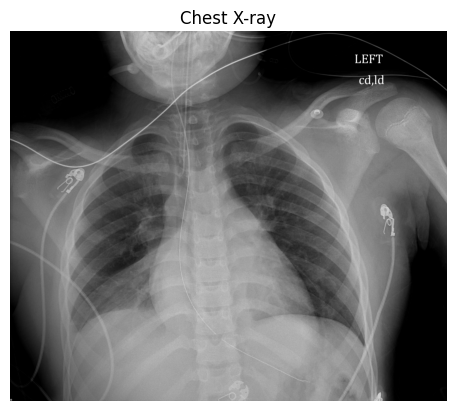

In [9]:
import pydicom
import matplotlib.pyplot as plt

# Replace with your actual path
dcm_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/HUM00237109/142427_001/20250606_XR CHEST PORTABLE 1 VIEW/1.2.840.114089.1.0.1.2887034108.1758184754.3712.136049_UNKNOWN_INSTANCE_TIME.dcm"

# Read the DICOM file
ds = pydicom.dcmread(dcm_path)

# Print metadata (Patient info, Study date, Modality, etc.)
print(ds)

# Access pixel data
if hasattr(ds, "PixelData"):
    img = ds.pixel_array
    print("Image shape:", img.shape)

    # Display
    plt.imshow(img, cmap="gray")
    plt.title("Chest X-ray")
    plt.axis("off")
    plt.show()
else:
    print("No pixel data found in this DICOM.")


### CXRs information table

In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Per-file information table (~3123 rows) + Crosswalk-expanded matches.

What this script does
---------------------
1) Read all DICOM headers (no pixels) under HUM00237109 (or dicom_index.csv if present).
2) Build a per-file table with key normalization tags and grouping columns:
   - StudyKey = MRN|StudyInstanceUID
   - StudyOrdinalPerMRN = deterministic order within each MRN using (StudyDate, StudyTime, Series#, Instance#, path)
3) Load Excel (TRAP-PARDS_cxr.xlsx):
   - OrdersAccessionNumbers: AccessionNumber -> PatientID
   - PatientInfo: PatientID -> MRN (if present)
4) Join per-file rows:
   - By AccessionNumber -> PatientID -> PatientInfo_MRN
   - Also add Crosswalk (De-ID MRN/ACC), expanded to per-file matches
5) Outputs:
   - files_master.csv               (per DICOM file; canonical table you asked for)
   - crosswalk_expanded_files.csv   (Crosswalk exploded to matching files)
   - files_unmatched_crosswalk.csv  (files with AccessionNumber not in Crosswalk)
   - crosswalk_unmatched_files.csv  (Crosswalk ACCs with zero matching files)
"""

from pathlib import Path
import re
import pandas as pd
import pydicom

# ---------------- Paths ----------------
ROOT = Path("/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/HUM00237109")
INDEX = ROOT / "dicom_index.csv"
CROSSWALK = ROOT / "Crosswalk.csv"

EXCEL_PATH = Path("/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXR(from_Joe)/TRAP-PARDS_cxr.xlsx")
SHEET_ORDERS_ACC = "OrdersAccessionNumbers"
SHEET_PATIENT    = "PatientInfo"

# ---------------- Outputs ----------------
OUT_FILES       = ROOT / "files_master.csv"
OUT_XW_EXP      = ROOT / "crosswalk_expanded_files.csv"
OUT_FILES_UNM   = ROOT / "files_unmatched_crosswalk.csv"
OUT_XW_UNM      = ROOT / "crosswalk_unmatched_files.csv"

# ---------------- Helpers ----------------
def list_dicoms():
    if INDEX.exists():
        df = pd.read_csv(INDEX, dtype=str)
        if "dicom_path" not in df.columns:
            raise RuntimeError(f"{INDEX} missing 'dicom_path' column")
        return sorted(df["dicom_path"].dropna().tolist())
    return sorted(str(p) for p in ROOT.rglob("*.dcm"))

def extract_mrn(path_str: str):
    p = Path(path_str)
    try:
        rel = p.resolve().relative_to(ROOT.resolve())
        parts = rel.parts
        return parts[0] if len(parts) >= 1 else None
    except Exception:
        m = re.search(r"/HUM00237109/([^/]+)/", path_str)
        return m.group(1) if m else None

def safe_get(ds, name):
    try:
        v = getattr(ds, name)
        if v is None:
            return None
        return str(v)
    except Exception:
        return None

def first_nonempty(series):
    for v in series:
        if pd.notna(v) and str(v) != "":
            return v
    return ""

def parse_int(x):
    try:
        return int(str(x))
    except Exception:
        return None

def find_col(df, name_options):
    cols = {c.lower(): c for c in df.columns}
    for opt in name_options:
        if opt.lower() in cols:
            return cols[opt.lower()]
    return None

# ---------------- 1) Read DICOM headers (per-file rows) ----------------
print("[INFO] Gathering DICOM files...")
paths = list_dicoms()
if not paths:
    raise SystemExit("No .dcm files found.")
print(f"[INFO] Reading headers from {len(paths)} files ...")

rows = []
for i, p in enumerate(paths, 1):
    mrn = extract_mrn(p)
    try:
        ds = pydicom.dcmread(p, stop_before_pixels=True, force=True)
        row = {
            "dicom_path": p,
            "filename": Path(p).name,
            "MRN_path": mrn,  # MRN from folder name
            # Core identifiers
            "StudyInstanceUID": safe_get(ds, "StudyInstanceUID"),
            "SeriesInstanceUID": safe_get(ds, "SeriesInstanceUID"),
            "SOPInstanceUID":   safe_get(ds, "SOPInstanceUID"),
            # Clinical keys
            "AccessionNumber":  safe_get(ds, "AccessionNumber"),
            "PatientID_dicom":  safe_get(ds, "PatientID"),
            "StudyDate":        safe_get(ds, "StudyDate"),
            "StudyTime":        safe_get(ds, "StudyTime"),
            "SeriesDate":       safe_get(ds, "SeriesDate"),
            "SeriesTime":       safe_get(ds, "SeriesTime"),
            "StudyDescription": safe_get(ds, "StudyDescription"),
            "SeriesDescription":safe_get(ds, "SeriesDescription"),
            "Modality":         safe_get(ds, "Modality"),
            "BodyPartExamined": safe_get(ds, "BodyPartExamined"),
            "ViewPosition":     safe_get(ds, "ViewPosition"),
            "ImageLaterality":  safe_get(ds, "ImageLaterality"),
            "SeriesNumber":     safe_get(ds, "SeriesNumber"),
            "InstanceNumber":   safe_get(ds, "InstanceNumber"),
            # Normalization-relevant tags
            "Rows":             safe_get(ds, "Rows"),
            "Columns":          safe_get(ds, "Columns"),
            "PhotometricInterpretation": safe_get(ds, "PhotometricInterpretation"),
            "BitsAllocated":    safe_get(ds, "BitsAllocated"),
            "BitsStored":       safe_get(ds, "BitsStored"),
            "HighBit":          safe_get(ds, "HighBit"),
            "PixelRepresentation": safe_get(ds, "PixelRepresentation"),
            "PixelSpacing":     safe_get(ds, "PixelSpacing"),
            "ImagerPixelSpacing": safe_get(ds, "ImagerPixelSpacing"),
            "RescaleIntercept": safe_get(ds, "RescaleIntercept"),
            "RescaleSlope":     safe_get(ds, "RescaleSlope"),
            "WindowCenter":     safe_get(ds, "WindowCenter"),
            "WindowWidth":      safe_get(ds, "WindowWidth"),
            "KVP":              safe_get(ds, "KVP"),
            "ExposureTime":     safe_get(ds, "ExposureTime"),
            "XRayTubeCurrent":  safe_get(ds, "XRayTubeCurrent"),
            "Exposure":         safe_get(ds, "Exposure"),
            "ExposureIndex":    safe_get(ds, "ExposureIndex"),
            "TargetExposureIndex": safe_get(ds, "TargetExposureIndex"),
            "DeviationIndex":   safe_get(ds, "DeviationIndex"),
            # File meta / transfer syntax
            "TransferSyntaxUID": safe_get(ds.file_meta, "TransferSyntaxUID") if getattr(ds, "file_meta", None) else None,
            "SOPClassUID":       safe_get(ds, "SOPClassUID"),
        }
    except Exception as e:
        row = {
            "dicom_path": p, "filename": Path(p).name, "MRN_path": mrn,
            "read_error": str(e)
        }
    rows.append(row)
    if i % 1000 == 0 or i == len(paths):
        print(f"  - {i}/{len(paths)}")

files_df = pd.DataFrame(rows)

# ---------------- 2) Build grouping columns (StudyKey + StudyOrdinalPerMRN) ----------------
valid = files_df.dropna(subset=["MRN_path","StudyInstanceUID"]).copy()
valid["SeriesNumber_int"] = valid["SeriesNumber"].map(parse_int)
valid["InstanceNumber_int"] = valid["InstanceNumber"].map(parse_int)

# For ordering per MRN: (StudyDate, StudyTime, min Series#, min Instance#, min path)
order_refs = (
    valid.groupby(["MRN_path","StudyInstanceUID"], as_index=False)
    .agg(
        StudyDate_min=("StudyDate", first_nonempty),
        StudyTime_min=("StudyTime", first_nonempty),
        SeriesNumber_min=("SeriesNumber_int", lambda s: min([x for x in s if x is not None], default=9999999)),
        InstanceNumber_min=("InstanceNumber_int", lambda s: min([x for x in s if x is not None], default=9999999)),
        FirstPath=("dicom_path", "min")
    )
)
order_refs = order_refs.sort_values(
    ["MRN_path","StudyDate_min","StudyTime_min","SeriesNumber_min","InstanceNumber_min","FirstPath"]
).reset_index(drop=True)

# Assign ordinal per MRN
order_refs["StudyOrdinalPerMRN"] = (
    order_refs.groupby("MRN_path").cumcount() + 1
)

# Merge back to files
order_refs["StudyKey"] = order_refs["MRN_path"] + "|" + order_refs["StudyInstanceUID"]
files_df = files_df.merge(order_refs[["MRN_path","StudyInstanceUID","StudyOrdinalPerMRN","StudyKey"]],
                          on=["MRN_path","StudyInstanceUID"], how="left")

# ---------------- 3) Load Excel (OrdersAccessionNumbers + PatientInfo) ----------------
print("[INFO] Loading Excel sheets (OrdersAccessionNumbers, PatientInfo)...")
xls = pd.ExcelFile(EXCEL_PATH, engine="openpyxl")
orders_acc = xls.parse(SHEET_ORDERS_ACC).copy()
patient    = xls.parse(SHEET_PATIENT).copy()

for df in (orders_acc, patient):
    for c in df.columns:
        df[c] = df[c].astype(str)

col_accnum   = find_col(orders_acc, ["AccessionNumber","acc","Accession Number"])
col_patient  = find_col(orders_acc, ["PatientID","Patient Id","Patient ID"])
if not col_accnum or not col_patient:
    raise SystemExit("OrdersAccessionNumbers sheet must contain AccessionNumber and PatientID.")

orders_acc_sub = orders_acc[[col_accnum, col_patient]].drop_duplicates()
orders_acc_sub.columns = ["AccessionNumber","PatientID"]

col_pid  = find_col(patient, ["PatientID","Patient Id","Patient ID"])
col_mrn2 = find_col(patient, ["MRN","De-ID MRN","DeID MRN"])
patient_cols = ["PatientID"] + ([col_mrn2] if col_mrn2 else [])
patient_sub = patient[patient_cols].drop_duplicates()
patient_sub.columns = ["PatientID"] + (["PatientInfo_MRN"] if col_mrn2 else [])

# Join: files_df (per file) <- AccessionNumber -> PatientID -> PatientInfo_MRN
files_df = files_df.merge(orders_acc_sub, on="AccessionNumber", how="left")
files_df = files_df.merge(patient_sub, on="PatientID", how="left")

# ---------------- 4) Load Crosswalk and expand to per-file matches ----------------
xw = pd.read_csv(CROSSWALK, dtype=str).fillna("")
if not {"De-ID MRN","De-ID ACC"}.issubset(xw.columns):
    raise SystemExit(f"Crosswalk must have 'De-ID MRN' and 'De-ID ACC' columns. Found: {list(xw.columns)}")

# Expand: Crosswalk ACC ↔ files by AccessionNumber match (this may yield multiple rows per ACC)
xw_expanded = xw.merge(
    files_df,
    left_on="De-ID ACC", right_on="AccessionNumber",
    how="left",
    suffixes=("","_file")
)

# ---------------- 5) Unmatched reports ----------------
# Files with AccessionNumber not present in Crosswalk ACCs
files_unmatched = files_df[~files_df["AccessionNumber"].isin(xw["De-ID ACC"])].copy()

# Crosswalk rows whose ACC has no matching files
xw_unmatched = xw[~xw["De-ID ACC"].isin(files_df["AccessionNumber"])].copy()

# ---------------- 6) Save outputs ----------------
files_df.to_csv(OUT_FILES, index=False)
xw_expanded.to_csv(OUT_XW_EXP, index=False)
files_unmatched.to_csv(OUT_FILES_UNM, index=False)
xw_unmatched.to_csv(OUT_XW_UNM, index=False)

print("\n========== SUMMARY ==========")
print(f"Total files (.dcm)                  : {len(files_df)}")
print(f"Unique studies (by StudyInstanceUID): {files_df['StudyInstanceUID'].nunique()}")
print(f"Crosswalk rows                      : {len(xw)}")
print(f"Crosswalk-expanded rows             : {len(xw_expanded)}")
print(f"Files unmatched to Crosswalk        : {len(files_unmatched)} -> {OUT_FILES_UNM.name}")
print(f"Crosswalk ACCs with no files        : {len(xw_unmatched)} -> {OUT_XW_UNM.name}")
print("Artifacts:")
print(f" - {OUT_FILES.name}  (one row per DICOM file; includes StudyKey & StudyOrdinalPerMRN)")
print(f" - {OUT_XW_EXP.name} (Crosswalk exploded to files)")
print(f" - {OUT_FILES_UNM.name}")
print(f" - {OUT_XW_UNM.name}")
print("=============================\n")


[INFO] Gathering DICOM files...
[INFO] Reading headers from 3123 files ...
  - 1000/3123
  - 2000/3123
  - 3000/3123
  - 3123/3123
[INFO] Loading Excel sheets (OrdersAccessionNumbers, PatientInfo)...

========== SUMMARY ==========
Total files (.dcm)                  : 3123
Unique studies (by StudyInstanceUID): 2969
Crosswalk rows                      : 2970
Crosswalk-expanded rows             : 3124
Files unmatched to Crosswalk        : 0 -> files_unmatched_crosswalk.csv
Crosswalk ACCs with no files        : 1 -> crosswalk_unmatched_files.csv
Artifacts:
 - files_master.csv  (one row per DICOM file; includes StudyKey & StudyOrdinalPerMRN)
 - crosswalk_expanded_files.csv (Crosswalk exploded to files)
 - files_unmatched_crosswalk.csv
 - crosswalk_unmatched_files.csv



In [12]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Combine files_master.csv + crosswalk_expanded_files.csv
into a single analysis-ready master table.

Adds:
- unified MRN column (De-ID MRN preferred, fallback MRN_path)
- normalization-ready numeric fields
- simple QC flags
"""

import pandas as pd
from pathlib import Path

ROOT = Path("/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw")
f_files = ROOT / "files_master.csv"
f_xwexp = ROOT / "crosswalk_expanded_files.csv"
f_out   = ROOT / "analysis_master.csv"

# ---- 1) Load ----
files = pd.read_csv(f_files, dtype=str)
xwexp = pd.read_csv(f_xwexp, dtype=str)

# ---- 2) Merge on unique key: AccessionNumber + SOPInstanceUID ----
merged = xwexp.merge(
    files,
    on=["AccessionNumber","SOPInstanceUID"],
    how="outer",
    suffixes=("","_file")
)

# ---- 3) Unify key identifiers ----
merged["MRN_final"] = merged["De-ID MRN"].fillna(merged["MRN_path"])
merged["ACC_final"] = merged["De-ID ACC"].fillna(merged["AccessionNumber"])

# ---- 4) Type-cast normalization columns ----
def to_float(x):
    try: return float(str(x).replace("[","").replace("]","").split(",")[0])
    except: return None

merged["Rows"] = pd.to_numeric(merged["Rows"], errors="coerce")
merged["Columns"] = pd.to_numeric(merged["Columns"], errors="coerce")
merged["RescaleSlope"] = pd.to_numeric(merged["RescaleSlope"], errors="coerce")
merged["RescaleIntercept"] = pd.to_numeric(merged["RescaleIntercept"], errors="coerce")
merged["WindowCenter"] = pd.to_numeric(merged["WindowCenter"].apply(to_float))
merged["WindowWidth"] = pd.to_numeric(merged["WindowWidth"].apply(to_float))

# Pixel spacing: keep both Imager and normal, also extract numeric mean
def spacing_mean(v):
    if pd.isna(v): return None
    s = str(v).strip("[]()")
    try:
        parts = [float(x) for x in re.split(r"[,\\s]+", s) if x]
        return sum(parts)/len(parts) if parts else None
    except: return None

import re
merged["PixelSpacing_mean"] = merged["PixelSpacing"].apply(spacing_mean)
merged["ImagerPixelSpacing_mean"] = merged["ImagerPixelSpacing"].apply(spacing_mean)

# ---- 5) Simple QC / convenience ----
merged["QC_missing_spacing"] = merged["PixelSpacing_mean"].isna()
merged["QC_missing_dims"] = merged[["Rows","Columns"]].isna().any(axis=1)

# ---- 6) Drop obvious duplicates ----
merged = merged.drop_duplicates(subset=["SOPInstanceUID"]).reset_index(drop=True)

# ---- 7) Save ----
merged.to_csv(f_out, index=False)
print(f"[SAVE] {f_out}  (n={len(merged)})")


[SAVE] /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/analysis_master.csv  (n=3124)


In [1]:
import pandas as pd

file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/PARDS_Risk_V3/2025_CXRs_Raw/analysis_master.csv"

df = pd.read_csv(file_path)

print(df.shape)
print(df.head())


(3124, 99)
            ACC   De-ID MRN      De-ID ACC  \
0  MMED41098036  142427_001  142427_001-01   
1  MMED41098607  142427_001  142427_001-02   
2  MMED40495421  142427_002  142427_002-01   
3  MMED40495851  142427_002  142427_002-02   
4  MMED40496056  142427_002  142427_002-03   

                                          dicom_path  \
0  /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Da...   
1  /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Da...   
2  /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Da...   
3  /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Da...   
4  /nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Da...   

                                            filename    MRN_path  \
0  1.2.840.114089.1.0.1.2887034108.1758184754.371...  142427_001   
1  1.2.840.114089.1.0.1.2887034108.1758184754.371...  142427_001   
2  1.2.840.114089.1.0.1.2887034108.1758184754.371...  142427_002   
3  1.2.840.114089.1.0.1.2887034108.1758184754.371...  142427_002   
4  1.2.840.114089.1.0.1.2887034108.